In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [12]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [14]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [15]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop('Cabin', axis=1)

In [16]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [17]:
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

y = df['Survived']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [20]:
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 77.09497206703911 %


In [22]:
prediction = model.predict([[3, 1, 22, 7.25, 0]])

print("Prediction:", prediction)

Prediction: [1]


C:\Users\Navya B\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


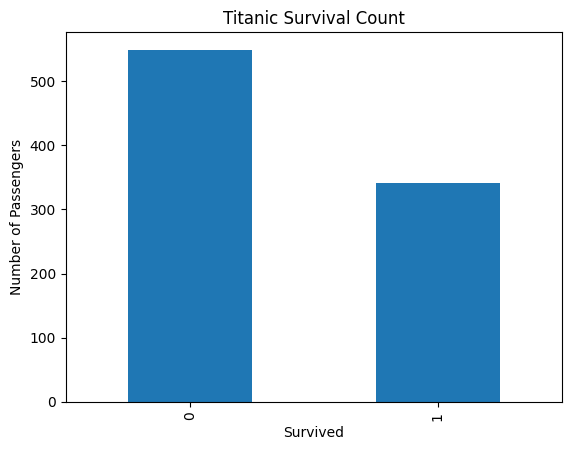

In [23]:
df['Survived'].value_counts().plot(kind='bar')

plt.title("Titanic Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

In [24]:
print("Titanic Survival Prediction Project Completed")

Titanic Survival Prediction Project Completed
